# Investigate Thematic Divergence

This notebook focussed on occurences of semantic divergence between the masked 'machine' token and the 'predictions'. We filtered predictions to only include sentences where the 'machine' is confused with another thematic area. This notebook focusses on the human-machine confusion. 

We there focus in human-type predictions, i.e. occurences where the LMs suggest as human-word as a filler for the machine token. 

For more information on the words we included, inspect `250_freq_pred_KB_edit.txt` and the `1-compute-gradients.ipynb`.


## What can this tell us?

We look at occurences where BERT confused the machine with human words.

We want to understand the divergence, and gauge, which **semantic** and **syntactic** patterns trigger the model towards 'human'-like predictions.

We can look more broadly which words exert push a pull related to (or away from) human or machine agency.

We only look at a smaller subset of examples, based on the existing top 10 predictions recorded in the spreadsheet created by Mariona.

We try to improve and add a few more features:
- a comparative analysis of newspapers and books, i.e. using both newspaper and book data as well as the model trained on these collections
- a more refined syntactic analysis, which includes the syntactic relation of the context token to the masked token

# On Terminology



### A thematic analysis, contrasting two concepts.

We want to understand the semantic intermingling of two distinct concepts, more specifically how the machine are related to, or portrayed as, 'human'-like entities. In this scenario, 'machine' is the TargetMaskedToken (the token that actually appeared in the text) and 'human' is the **predicted contrastive theme**, i.e. a set of thematically related words, predicted by BERT in the position of the masked machine token.

### Target vs. Contrastive Theme

One of the concepts is the **"target concept"**, to other one the **"contrastive concept"**. Each analysis starts with a target concept or token, or `TargetMaskedToken`, this is the starting point of the analysis, for example the word 'machine'. This tokens has two associated datasets. 
    - a TargetMaskedToken maps onto a set of workds that capture the target concept
    - sentences which contain the masked token (`df_target_sent`)
    - contribution obtained by from the integrated gradients method (abbr "ig", `df_target_ig`) 

The `TargetMaskedToken` related to a `ContrastiveTheme`, in this case 'human' like entitites which we filtered from BERT predictions. 

To understand language model predictions, we study both the `TargetMaskedToken` and the `ContrastiveTheme` in two scenarios: **observed** and **counterfactual**. 

 Observed refers to scenarios in which the target of constrastive token appears in the sentences. We than look what tokens contribute to predicting the actual word use. 
 
 In counterfactual scenarios, we measure which words contributed to the ''wrong'' predictions, i.e. what caused BERT to confuse machines with human entities?

## Setting things up and loading the data

In [97]:
import pandas as pd
import json
from tqdm import tqdm
from explain import *
from pathlib import Path

In [98]:
collection,genre_suffix = 'blb',''
if collection == 'blb':
  genre_suffix = '_with_genre'

TargetMaskedToken = 'machine' # the token to be masked in the target sentence

dataPath = 'input_data' # change to '.' when working in colab 
processedFolder = 'gradient_data' # change '.' when working in colab
predCol = "pred_bert_1760_1900"
resultType = 'pred_kw_filtered' # pred | pred_kw_filter

print(f"This analysis focuses on '{TargetMaskedToken}'.")

This analysis focuses on 'machine'.


In [99]:
# load the original sentences with the predicted tokens
df_sent = pd.read_csv(f'{dataPath}/{collection}_{TargetMaskedToken}{genre_suffix}_{resultType}.tsv', index_col=0, sep='\t').reset_index(drop=True)
print(f'We have {df_sent.shape[0]} sentences for the target token {TargetMaskedToken} in the {collection} collection.')
df_ig = pd.read_csv(f'{processedFolder}/results_{collection}_{TargetMaskedToken}_{resultType}_processed.csv', index_col=0 )
print(f'We have {df_ig.shape[0]} explanations for the target token {TargetMaskedToken}.')


We have 19003 sentences for the target token machine in the blb collection.
We have 2173047 explanations for the target token machine.


In [100]:
# check if ids are aligned between gradient data and sentences
print(df_ig['id'].nunique(), df_sent.shape[0])
print(df_ig[df_ig['id'] == 0].Token, df_sent.iloc[0].currentSentence) 

19003 19003
0               "
1            upon
2             the
3          ground
4               -
          ...    
137    fanatacism
138            of
139     crusaders
140             .
141             "
Name: Token, Length: 142, dtype: str " Upon the ground - where they had kneeled, His men would die or win the field, — " and friends and adversaries alike bear testimony, that in his camp, — " the most rigid discipline was found in company with the fiercest resolution; that his troops moved to victory with the precision of machines, while burning with the wildest fanatacism of crusaders. "


# Pushing towards Humanity

To find our which contextual element push the prediction to towards "human" type entitites, we start with the most generic type of question, just looking at all the all the words within the sentence across all the different (human-type) predictions.

Let's see which contextual tokens push BLERT to predicting human-like entities. Please note that the analysis below repeats sentencess, we look at all sentences and all the filtered keywords.

In [102]:

targetTokens = ['machine','machines']
df_comparisonConcept = df_ig[
    (~df_ig['Target'].isin(targetTokens)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_score=('Score', 'mean')
                    ).reset_index()


In [80]:
# please note that this repeats sentences, this acros all sentences with all the filtered keywords
min_count = 10
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)
df_result.head(10)

,Token,count,identifiers,avg_score
32576,toy,10,"{18283, 3725, 18542, 11440, 8913, 3282, 8469}",0.429404
27104,rides,12,"{17736, 3850, 17681, 4466, 3829, 17053}",0.403356
22789,operators,15,"{6690, 11275, 1039, 11125, 12181, 12119, 15832, 15166}",0.399010
18874,lating,13,"{10496, 4354, 3527, 11638, 888}",0.353806
27584,ry,45,"{12034, 2055, 2697, 2059, 13844, 8213, 13207, 9118, 11423, 15774, 18974, 7330, 13862, 10792, 6057, 6189, 9390, 2357, 2359, 3898, 18749, 7620, 1872, 2770, 6483, 16468, 9173, 4699, 16351, 5728, 227,...",0.348455
19064,legislative,29,"{13442, 6793, 13325, 15889, 12692, 3605, 3606, 13851, 17179, 4766, 1822, 11313, 11314, 4169, 2386, 9682, 13150, 13151, 1896, 3563, 1774, 15474, 6652}",0.336990
11403,electrical,67,"{18563, 18442, 6036, 16404, 17044, 4377, 10265, 12447, 11556, 18981, 3622, 16167, 8360, 17450, 939, 18988, 1198, 1330, 1331, 16179, 10165, 17842, 18998, 6204, 3901, 15036, 16064, 15176, 16843, 162...",0.334636
28794,shops,2494,"{8204, 8206, 8209, 8212, 8213, 8218, 8220, 8221, 31, 32, 33, 34, 35, 36, 37, 38, 8225, 8226, 41, 42, 8227, 44, 45, 8233, 48, 50, 51, 52, 8242, 8245, 57, 58, 59, 16443, 61, 16445, 63, 16446, 16447,...",0.330775
8769,crusaders,11,"{0, 17569, 17570, 2951, 12200, 16072, 14480, 14481, 2970}",0.322467
35528,wits,13,"{9179, 10635, 14919, 10671}",0.320851


# Explore Subthemes

Ok, the above is maybe not very helpful. Let's look at subthemes, e.g. 'child' or 'woman' related terms, both together as well as individually?

In [103]:
wordList = ['child','children','boy','girl', 'boys', 'girls','baby','babies']

df_comparisonConcept = df_ig[
    (df_ig['Target'].isin(wordList)) # we exclude the target token itself, as we are interested in other tokens that are predictive of the contrastive concept
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_score=('Score', 'mean')
                    ).reset_index()


In [104]:

min_count = 10
df_result = df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False)
df_result.head(10)

,Token,count,identifiers,avg_score
4838,mowing,15,"{13026, 4579, 4580, 10181, 11942, 10024, 17484, 589, 8815, 8784, 434, 7385, 7418, 18268, 15358}",0.360795
4667,mere,354,"{9217, 15367, 15879, 17927, 7179, 3599, 3091, 4628, 2583, 13337, 17433, 13341, 18462, 17439, 15392, 18979, 3625, 8746, 7726, 10286, 15920, 10289, 6709, 15416, 17977, 4667, 6207, 13375, 4673, 4674,...",0.315697
4506,man,238,"{12288, 16386, 9220, 5, 4101, 5641, 7179, 9227, 18454, 18455, 5656, 13337, 13341, 17949, 17439, 1568, 6182, 11307, 4652, 2095, 5167, 2611, 1087, 4672, 4674, 12356, 581, 72, 2122, 5196, 17484, 1799...",0.311965
2322,dozen,10,"{13410, 5027, 5904, 14577, 17234, 4181, 8028}",0.302689
6583,sewing,214,"{17920, 1, 2, 3, 13314, 18947, 10, 11, 524, 12810, 13326, 12816, 12818, 13335, 4120, 15898, 7711, 1568, 2592, 7714, 11808, 16931, 17449, 557, 5172, 4150, 1592, 8253, 6718, 8261, 9803, 9804, 10832,...",0.298924
6841,soldier,17,"{640, 8257, 5603, 5541, 15879, 4588, 10287, 5168, 12207, 9783, 14586, 7422, 5951}",0.287135
834,bathing,52,"{8833, 10629, 6790, 15110, 3592, 11150, 1424, 2576, 12823, 1945, 18299, 16687, 1585, 11953, 7477, 6842, 6974, 958, 3392, 9279, 9280, 16576, 2634, 2514, 7634, 7764, 7637, 9045, 7895, 17625, 11226, ...",0.284496
6553,servant,16,"{2305, 14785, 13315, 17506, 4550, 5547, 10475, 11998, 5275, 8542}",0.281555
1420,child,55,"{12427, 11021, 12431, 10770, 918, 6040, 924, 18465, 18466, 11043, 6182, 16687, 13234, 15156, 14010, 2747, 18622, 11971, 4167, 14285, 7634, 7764, 982, 1754, 6493, 3037, 8158, 11486, 5601, 7523, 445...",0.279318
3674,horse,13,"{6593, 6182, 18793, 5900, 13613, 13234, 17012, 6040, 17436, 18591}",0.274948


In [105]:
pd.set_option('display.max_colwidth', 200)
df_sent.iloc[list(df_result.loc[6841].identifiers)].currentSentence

640                                                                                                                                       The French soldier is not a mere machine in the eyes of his superiors.
8257                            A kiss as well, or damn me if I do not put this young kissing machine beneath my trusty blade, " said a drunken soldier, breaking suddenly in upon the sweetness of their tryst.
5603                                                                                                   The English soldier fights, whde in the army, with all the bravery of the Briton, but it is as a machine.
5541     If we governed, should we take the boy of poor parents, just as he was able to repay them for some of their painful care, and 165 THE STORY OF CHRISTINE ROCHEFORT send him to waste three of his be...
15879                       In this costume, with a suitable instruction in the mystery of marching and countermarching, he is as mere a machine, and, consequently,

# Zoom in on examples

In [11]:
modelName = "Livingwithmachines/bert_1760_1900"
explainer = MaskedLMExplainer(model_name=modelName, device=pick_device())

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
idx = 8257
sentence = df_sent.iloc[idx].maskedSentence
targets =list(set(df_ig[df_ig['id'] == idx].Target.unique()).intersection(set(wordList)))

In [13]:
print(f"Sentence: {sentence}")
print(f"Targets: {targets}")

Sentence: A kiss as well , or damn me if I do not put this young kissing [MASK] beneath my trusty blade , " said a drunken soldier , breaking suddenly in upon the sweetness of their tryst .
Targets: ['girl']


In [14]:
# select target
target = targets[0] 

In [15]:

highlight_context_tokens(explainer, sentence, target=target, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_734224902c684abeba3459249cc62542">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>girl</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.079899\' style=\'background:rgba(30, 136, 229, 0.272); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>a</span> <span class=\'tok\' data-score=\'0.280614\' style=\'background:rgba(30, 136, 229, 0.705); padding:2px 4px; margin:1p

Rank the sentences by decreasing value of the context word on the predicted word.

In [16]:
target = 'girl'
context_token = 'mowing'
ordered_idx = df_ig[(df_ig['Target']== target) & ((df_ig['Token']==context_token))].sort_values(by='Score', ascending=False)['id'].values

In [17]:
df_sent.iloc[ordered_idx].currentSentence

18268                                                                                                            I felt that in the presence of the gardener and the mowing machine I should be more at my ease.
589                                                                                       — hopping and quarrelling and twittering up and down upon his ladder; may see Jacob and the mowing machine; and — her.
4579                            Phœbe noticed A FAMILIAR TOUCH. 119 that Avice looked whiter than ever as she stood by the mowing machine talking to the old gardener, and ca Ued to her to come into the shade.
10024    And then, just as Miss Sybella was about to respond joyfully, the conference came to an end by a donkey, which was drawing the mowing machine over the lawn in front, beginning to hee haw, and May ...
4580     " We want to hear how you like your busy Use, and to be sure that you are not overworking, " Miss Joy said, by and by, as they sat under the tulip tree, an

In [18]:
sentence = df_sent.iloc[18268].maskedSentence
highlight_context_tokens(explainer, sentence, target=target, word_agg="mean")

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

'\n    <div id="tokviz_92c520b5918343f49e341d0edb803b95">\n      <div style=\'margin-bottom:6px;\'>\n        <b>Target:</b> <code>girl</code>\n      </div>\n      <div style=\'margin:6px 0 10px 0; font-size:13px; display:flex; gap:10px; align-items:center;\'>\n        <span style=\'background:rgba(30,136,229,0.35); padding:2px 8px; border-radius:4px;\'>&#9646; predicts</span>\n        <span style=\'background:rgba(229,57,53,0.35);  padding:2px 8px; border-radius:4px;\'>&#9646; opposes</span>\n        <span style=\'background:rgba(255,193,7,0.85);  padding:2px 8px; border-radius:4px; font-weight:bold;\'>[target] mask position</span>\n      </div>\n      <div style=\'line-height:2.4; font-size:15px;\'>\n        <span class=\'tok\' data-score=\'0.065998\' style=\'background:rgba(30, 136, 229, 0.224); padding:2px 4px; margin:1px; border-radius:4px; cursor:default;\'>i</span> <span class=\'tok\' data-score=\'0.083505\' style=\'background:rgba(30, 136, 229, 0.257); padding:2px 4px; margin:1p

## LLM interrogation of a result set

In [47]:
from explain.gpt_annotation import run_gpt_preannotation
OPENAI_API_KEY = ''  # leave blank to use environment variable OPENAI_API_KEY
OPENAI_MODEL = 'gpt-4o'
OPENAI_MAX_WORKERS = 5

COT_SYSTEM_PROMPT = '''You are an expert historian reading excerpts from 19th-century British books.
We want to explore the idea that nineteenth‑century discourse often treats humans, machines, animals, and slaves as interchangeable labouring entities within a shared conceptual field.

Analyse the sentences, and assess to what extent they portray machine as being "alive" or "human-like". 
Do the sentences express anthropomorphism (machines treated as alive) or technomorphism (humans described as machines)?
Consider the context, the actions described, and any anthropomorphic or technomorphic language used. 

Think step-by-step, then output ONLY a JSON object in this exact format (no markdown, no prose, no backticks):
{"reasoning": "<chain-of-thought reasoning>", "label": "anthropomorphic", "technomorphic", or "none"}
'''


In [48]:
df_sample = pd.DataFrame(df_sent.iloc[list(df_result.loc[6841].identifiers)].currentSentence)
df_sample.rename(columns={'currentSentence':'sentence'}, inplace=True)

df_sample.reset_index(drop=True)
df_sample['label'] = ''
df_sample['reasoning'] = ''
df_sample.head(10)

,sentence,label,reasoning
640,The French soldier is not a mere machine in the eyes of his superiors.,,
8257,"A kiss as well, or damn me if I do not put this young kissing machine beneath my trusty blade, "" said a drunken soldier, breaking suddenly in upon the sweetness of their tryst.",,
5603,"The English soldier fights, whde in the army, with all the bravery of the Briton, but it is as a machine.",,
5541,"If we governed, should we take the boy of poor parents, just as he was able to repay them for some of their painful care, and 165 THE STORY OF CHRISTINE ROCHEFORT send him to waste three of his be...",,
15879,"In this costume, with a suitable instruction in the mystery of marching and countermarching, he is as mere a machine, and, consequently, as good a soldier, as can well be imagined.",,
4588,"On one occasion, when at drill, Gould called out to the regiment — "" Steady, gentle men, steady; a soldier is a mere machine.",,
10287,"The soldier boys resorted to all sorts of expedients to "" beat the machine. """,,
5168,"The instruc tion imparted at Hythe is chiefly designed to heighten the soldier 's intelligence, for, OAving to the introduction of the rifle, he is bound hence forth to regard himself as an indivi...",,
12207,"The Russian soldier is a mere machine, without animation or enterprise, and, with the exception of the Kosacks, totally unfit to act as light troops.",,
9783,"The soldier was re garded as a sort of mechanical contrivance, capable of the most daring conduct, and of rendering the most valuable service as long as his officers were present to lead and direc...",,


In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from explain.gpt_annotation import run_gpt_preannotation

summary = run_gpt_preannotation(
    df_sample,
    system_prompt=COT_SYSTEM_PROMPT,
    api_key=OPENAI_API_KEY,
    model=OPENAI_MODEL,
    n=0,
    max_workers=OPENAI_MAX_WORKERS,
)

Sending 13 snippets to gpt-4o …
  13/13 done  (ok=13, errors=0)

Pre-annotation complete: {'sent': 13, 'ok': 13, 'errors': 0}


In [51]:
df_sample

,sentence,label,reasoning,gpt_error
640,The French soldier is not a mere machine in the eyes of his superiors.,technomorphic,"The sentence suggests that the French soldier is not viewed as a mere machine, implying that there is a tendency to view soldiers as machines. This reflects technomorphism, where humans (soldiers)...",
8257,"A kiss as well, or damn me if I do not put this young kissing machine beneath my trusty blade, "" said a drunken soldier, breaking suddenly in upon the sweetness of their tryst.",technomorphic,"The phrase 'young kissing machine' refers to a person, likely implying that the person is performing the action of kissing in a mechanical or repetitive manner. This is an example of technomorphis...",
5603,"The English soldier fights, whde in the army, with all the bravery of the Briton, but it is as a machine.",technomorphic,"The sentence describes the English soldier as fighting with bravery but qualifies this by saying it is 'as a machine.' This implies that the soldier's actions are mechanical, lacking individual ag...",
5541,"If we governed, should we take the boy of poor parents, just as he was able to repay them for some of their painful care, and 165 THE STORY OF CHRISTINE ROCHEFORT send him to waste three of his be...",technomorphic,"The sentence describes a boy being trained to become 'a mere machine of a soldier.' This implies that the boy, a human, is being described in terms of a machine, suggesting a transformation into s...",
15879,"In this costume, with a suitable instruction in the mystery of marching and countermarching, he is as mere a machine, and, consequently, as good a soldier, as can well be imagined.",technomorphic,"The sentence describes a soldier as being 'as mere a machine' when trained in marching and countermarching. This comparison suggests that the soldier, a human, is being described in terms of a mac...",
4588,"On one occasion, when at drill, Gould called out to the regiment — "" Steady, gentle men, steady; a soldier is a mere machine.",technomorphic,"The sentence explicitly states that 'a soldier is a mere machine,' which is a clear example of technomorphism. It describes humans, specifically soldiers, as machines, emphasizing their role as la...",
10287,"The soldier boys resorted to all sorts of expedients to "" beat the machine. """,none,"The phrase 'beat the machine' suggests a competitive or adversarial relationship between humans and machines. However, it does not explicitly describe the machine as being alive or human-like, nor...",
5168,"The instruc tion imparted at Hythe is chiefly designed to heighten the soldier 's intelligence, for, OAving to the introduction of the rifle, he is bound hence forth to regard himself as an indivi...",technomorphic,The sentence contrasts the soldier's previous perception as a machine with the new expectation to see himself as an individual due to the introduction of the rifle. This implies that soldiers were...,
12207,"The Russian soldier is a mere machine, without animation or enterprise, and, with the exception of the Kosacks, totally unfit to act as light troops.",technomorphic,"The sentence describes the Russian soldier as a 'mere machine,' indicating a lack of animation or enterprise. This comparison suggests that the soldier is being described in terms of a machine, em...",
9783,"The soldier was re garded as a sort of mechanical contrivance, capable of the most daring conduct, and of rendering the most valuable service as long as his officers were present to lead and direc...",technomorphic,"The snippet describes a soldier as a 'mechanical contrivance,' suggesting that the soldier is viewed as a machine that requires external direction to function. This is a clear example of technomor...",


In [64]:
from explain.gpt_annotation import run_gpt_preannotation
OPENAI_API_KEY = ''  # leave blank to use environment variable OPENAI_API_KEY
OPENAI_MODEL = 'gpt-4o'
OPENAI_MAX_WORKERS = 5

COT_SYSTEM_PROMPT = '''You are an average person living and reading in the 19th century.

Analyse the sentences, focuss on the [MASKED] token. What word would you expect to be in the [MASKED] position, based on the context of the sentence?

Think step-by-step, then output ONLY a JSON object in this exact format (no markdown, no prose, no backticks):
{"reasoning": "<chain-of-thought reasoning>", "label": "<expected_word>"}
'''


In [65]:
df_sample = pd.DataFrame(df_sent.iloc[list(df_result.loc[6841].identifiers)].maskedSentence)
df_sample.rename(columns={'maskedSentence':'sentence'}, inplace=True)

df_sample.reset_index(drop=True)
df_sample['label'] = ''
df_sample['reasoning'] = ''

In [66]:
from explain.gpt_annotation import run_gpt_preannotation

summary = run_gpt_preannotation(
    df_sample,
    system_prompt=COT_SYSTEM_PROMPT,
    api_key=OPENAI_API_KEY,
    model=OPENAI_MODEL,
    n=0,
    max_workers=OPENAI_MAX_WORKERS,
)

Sending 13 snippets to gpt-4o …
  13/13 done  (ok=13, errors=0)

Pre-annotation complete: {'sent': 13, 'ok': 13, 'errors': 0}


In [67]:
df_sample

,sentence,label,reasoning,gpt_error
640,The French soldier is not a mere [MASK] in the eyes of his superiors .,pawn,The sentence is discussing the perception of a French soldier by his superiors. The phrase 'not a mere' suggests that the word following it should be something that implies a lower status or a sim...,
8257,"A kiss as well , or damn me if I do not put this young kissing [MASK] beneath my trusty blade , "" said a drunken soldier , breaking suddenly in upon the sweetness of their tryst .",couple,The sentence describes a drunken soldier interrupting a romantic moment and threatening to use his blade. The phrase 'young kissing [MASK]' suggests that the masked word is a noun describing a per...,
5603,"The English soldier fights , whde in the army , with all the bravery of the Briton , but it is as a [MASK] .",lion,"The sentence is discussing the English soldier's bravery while in the army. The phrase 'it is as a' suggests a comparison or metaphor. In the 19th century, soldiers were often compared to lions fo...",
5541,"If we governed , should we take the boy of poor parents , just as he was able to repay them for some of their painful care , and 165 THE STORY OF CHRISTINE ROCHEFORT send him to waste three of his...",drudge,The sentence discusses the idea of taking a boy from poor parents and sending him to learn something that might not be very beneficial. The phrase 'mere [MASK] of a soldier' suggests that the word...,
15879,"In this costume , with a suitable instruction in the mystery of marching and countermarching , he is as mere a [MASK] , and , consequently , as good a soldier , as can well be imagined .",puppet,"The sentence describes someone in a costume who has been instructed in marching and countermarching, suggesting they are being compared to something or someone that is not genuinely a soldier but ...",
4588,"On one occasion , when at drill , Gould called out to the regiment — "" Steady , gentle men , steady ; a soldier is a mere [MASK] .",machine,The sentence is about a drill and the speaker is addressing soldiers. The phrase 'a soldier is a mere' suggests that the speaker is about to describe a soldier in a simplistic or fundamental way. ...,
10287,"The soldier boys resorted to all sorts of expedients to "" beat the [MASK] . """,drum,"The phrase 'beat the [MASK]' is often used in the context of overcoming or outsmarting something. In the context of soldiers, this phrase is commonly associated with 'beat the system' or 'beat the...",
5168,"The instruc tion imparted at Hythe is chiefly designed to heighten the soldier 's intelligence , for , OAving to the introduction of the rifle , he is bound hence forth to regard himself as an ind...",unit,"The sentence discusses the change in a soldier's role due to the introduction of the rifle. It suggests that previously, soldiers were not seen as individuals but rather as part of a collective or...",
12207,"The Russian soldier is a mere [MASK] , without animation or enterprise , and , with the exception of the Kosacks , totally unfit to act as light troops .",automaton,"The sentence describes the Russian soldier as lacking animation or enterprise, suggesting a lack of initiative or individuality. The word 'mere' implies something insignificant or basic. Given the...",
9783,"The soldier was re garded as a sort of mechanical contrivance , capable of the most daring conduct , and of rendering the most valuable service as long as his officers were present to lead and dir...",soldier,"The sentence describes a soldier as a mechanical contrivance that requires the presence and supervision of officers to function effectively. The context suggests that without this supervision, the...",


## Temporal Filtering

In [106]:
indices = df_sent[df_sent['date'].between(1850, 1900)].index

In [89]:
targetTokens = ['machine','machines']
df_comparisonConcept = df_ig[
    (~df_ig['Target'].isin(targetTokens)) & \
    (df_ig['id'].isin(indices))
                ].groupby('Token').agg(
                        count=('id', 'count'),identifiers=('id', set),avg_score=('Score', 'mean')
                    ).reset_index()


In [90]:
min_count = 50
df_comparisonConcept[df_comparisonConcept['count'] >= min_count].sort_values(by='avg_score', ascending=False).head(10)

,Token,count,identifiers,avg_score
25499,shops,2286,"{31, 32, 33, 34, 35, 36, 37, 38, 41, 42, 44, 45, 48, 50, 51, 52, 57, 58, 59, 16443, 61, 16445, 63, 16446, 16447, 68, 16456, 106, 107, 108, 109, 110, 111, 112, 16492, 114, 115, 120, 8313, 122, 125,...",0.335381
10088,electrical,57,"{18563, 18442, 6036, 16404, 4377, 10265, 12447, 11556, 18981, 3622, 16167, 8360, 17450, 939, 18988, 1330, 1331, 16179, 17842, 18998, 15036, 3901, 16064, 15176, 16843, 16205, 11471, 18520, 6236, 10...",0.324009
14454,human,1203,"{8194, 6150, 8, 4128, 6177, 18465, 6181, 2104, 65, 4162, 12357, 2121, 12365, 10319, 18512, 12369, 10322, 8276, 10332, 16480, 8294, 103, 105, 18537, 8299, 2156, 2157, 2161, 4212, 18555, 16508, 6273...",0.321146
15172,infernal,199,"{13312, 6658, 11269, 4616, 15886, 2065, 3601, 13343, 13857, 4642, 11307, 10285, 2607, 4147, 12346, 12347, 14403, 11341, 14926, 3664, 13909, 600, 14424, 15454, 13410, 13411, 13930, 18540, 8309, 118...",0.295556
5103,calculating,210,"{7296, 7425, 7426, 4355, 4357, 4360, 8719, 15380, 15894, 5911, 18583, 13083, 14491, 2590, 2591, 5152, 15006, 4898, 16292, 805, 2344, 4521, 15149, 1714, 2099, 6707, 7859, 6070, 16182, 16819, 3897, ...",0.284099
25493,shop,1570,"{18319, 16393, 18320, 4117, 14358, 4119, 18322, 16416, 6177, 12323, 18468, 39, 40, 43, 18477, 6190, 53, 56, 17138, 16935, 16443, 60, 16444, 62, 8254, 10304, 6209, 16448, 6211, 6212, 6213, 16451, 1...",0.282680
19004,mowing,125,"{3088, 6160, 1042, 4116, 11296, 9251, 10796, 13882, 11328, 3651, 3654, 17990, 17484, 589, 8784, 17490, 8283, 16989, 16482, 4713, 8815, 6784, 10379, 15504, 17053, 674, 3234, 11942, 8361, 4802, 1248...",0.280353
22148,press,323,"{7684, 18958, 15888, 2577, 11286, 6167, 6685, 7197, 9248, 8749, 559, 8752, 4145, 10804, 5687, 13385, 10828, 3672, 7264, 14948, 8303, 17009, 11892, 7798, 12409, 13437, 12943, 12945, 12946, 12948, 6...",0.278853
12196,foundry,637,"{12303, 4117, 14358, 4119, 16416, 36, 53, 56, 16445, 10304, 6209, 6211, 16451, 16452, 16454, 6215, 16457, 16458, 16459, 12364, 16460, 14416, 18514, 18515, 6246, 6247, 6248, 16488, 10347, 111, 2160...",0.271092
13432,guns,185,"{9728, 11271, 7688, 11272, 11786, 18969, 18970, 18971, 18972, 2595, 13353, 17962, 17963, 18995, 8758, 8759, 8760, 8761, 5178, 5179, 3132, 17983, 4672, 18018, 8809, 11884, 11885, 632, 633, 634, 139...",0.267012


# Temporal trends

In [107]:
df_ig_temporal = df_ig.merge(df_sent[['date']], left_on='id', right_index=True, how='left').fillna(-1)
df_ig_temporal['decade'] = (df_ig_temporal['date']//10)*10
df_ig_temporal.head()

,Token,Score,Target,id,Score_normalized,mask_syntax_relation,mask_constituent_relation,mask_token_distance,Target_position,Sentence_length,date,decade
0,"""",0.033010,soldiers,0,0.004199,-1,punct^|ccomp^|prepv|pobjv|prepv|pobjv|prepv|pobjv,59.0,0,142,1859,1850
1,upon,0.016913,soldiers,0,0.002152,-1,prep^|ccomp^|prepv|pobjv|prepv|pobjv|prepv|pobjv,58.0,0,142,1859,1850
2,the,-0.036130,soldiers,0,-0.004596,-1,det^|pobj^|prep^|ccomp^|prepv|pobjv|prepv|pobjv|prepv|pobjv,57.0,0,142,1859,1850
3,ground,0.047039,soldiers,0,0.005984,-1,pobj^|prep^|ccomp^|prepv|pobjv|prepv|pobjv|prepv|pobjv,56.0,0,142,1859,1850
4,-,0.010132,soldiers,0,0.001289,-1,punct^|ccomp^|prepv|pobjv|prepv|pobjv|prepv|pobjv,55.0,0,142,1859,1850


<Axes: title={'center': 'Average score for tokens "child" and "children" over years'}, xlabel='decade'>

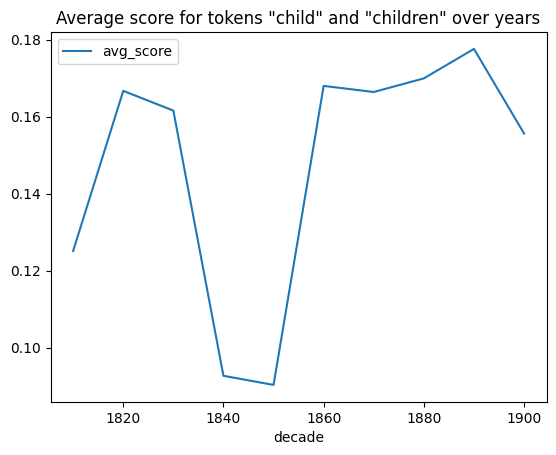

In [132]:
wordList = ['woman','women']#['boy','boys','girl','girls','child','children','baby','babies']
time_unit = 'decade' #| 'date'
by_time = df_ig_temporal[df_ig_temporal.Token.isin(wordList)].groupby(time_unit).agg(
    count=('id', 'count'),avg_score=('Score', 'mean')).reset_index()
by_time[by_time[time_unit] > 1800].plot(x=time_unit, y='avg_score', kind='line', title='Average score for tokens "child" and "children" over years')

<Axes: title={'center': 'Average score for token "child" over decades'}, xlabel='decade'>

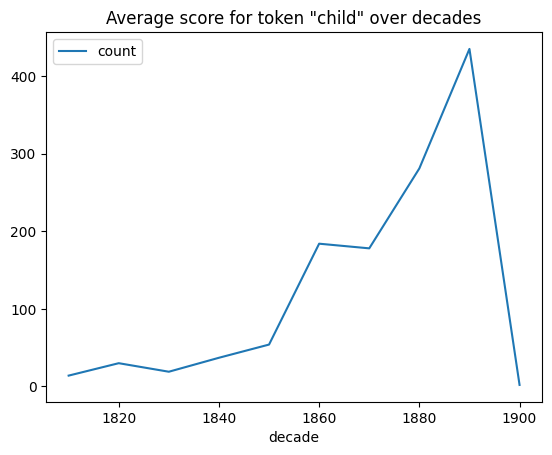

In [133]:
by_time[by_time[time_unit] > 1800].plot(x=time_unit, y='count', kind='line', title='Average score for token "child" over decades')

# Syntact Analysis

In [141]:
# look only at the tokens that are inside the [MASK] constituent
by_token = df_ig[~df_ig.mask_syntax_relation.isnull()].groupby(['Target','Token']).agg(count=('id', 'count'),identifiers=('id', list),avg_score=('Score', 'mean')).reset_index()

# look at the tokens with a specific relation to the [MASK] constituent
# by_token = df_ig[df_ig.mask_constituent_relation.isin(['nsubjv','nsubj^'])].groupby(['Target','Token']).agg(count=('id', 'count'),identifiers=('id', list),avg_score=('Score', 'mean')).reset_index()


In [142]:
min_count = 0
comparison_tokens = ['child','children']
target_tokens = ['machine','machines']

comparison = by_token[(by_token['Target'].isin(comparison_tokens)) & \
         (by_token['count'] >= min_count )
         ]
target = by_token[(by_token['Target'].isin(target_tokens)) & \
         (by_token['count'] >= min_count )
         ]
print(comparison.shape[0], target.shape[0])

449 5620


In [143]:
comparison = comparison.merge(target, on='Token', suffixes=('_kw', '_t'))
comparison['diff'] = comparison['avg_score_kw'] - comparison['avg_score_t']
comparison.sort_values(by='diff', ascending=False).head(20)


,Target_kw,Token,count_kw,identifiers_kw,avg_score_kw,Target_t,count_t,identifiers_t,avg_score_t,diff
537,children,factory,2,"[14767, 15145]",0.112270,machines,1,[15145],-0.762876,0.875146
280,child,nurse,2,"[18862, 18905]",0.666631,machines,1,[17993],-0.118155,0.784786
695,children,two,1,[13224],0.697601,machine,57,"[45, 59, 148, 809, 1266, 1550, 2492, 2493, 2929, 2953, 3173, 3371, 4504, 4516, 4568, 4803, 4913, 5374, 5977, 5986, 6075, 6189, 6256, 6407, 7130, 7221, 7246, 8760, 8851, 8896, 8897, 8910, 8922, 892...",0.057790,0.639811
519,children,educated,1,[14933],0.298064,machine,1,[17460],-0.259899,0.557963
164,child,heart,1,[2584],0.513095,machines,1,[15377],-0.037602,0.550698
667,children,tending,1,[11379],0.315217,machines,1,[11379],-0.230773,0.545990
651,children,several,1,[3833],0.678038,machine,35,"[139, 1983, 2909, 2916, 3259, 4200, 4369, 5983, 5984, 5985, 6527, 7242, 7300, 8612, 8617, 8645, 8684, 8688, 9038, 9120, 12129, 13720, 13751, 13763, 13780, 13794, 14982, 15223, 15435, 16718, 16721,...",0.151817,0.526221
254,child,nature,1,[2785],0.517999,machines,2,"[6560, 8975]",-0.000109,0.518109
567,children,human,2,"[11639, 13327]",0.722834,machines,49,"[180, 814, 1573, 1800, 2104, 2157, 3019, 3022, 3564, 3626, 4162, 4634, 5484, 5576, 5973, 6661, 6662, 6944, 7233, 7474, 7528, 7900, 8040, 8119, 8322, 8462, 8478, 8780, 8793, 9379, 11627, 11639, 116...",0.231812,0.491022
571,children,its,1,[12348],0.495776,machines,9,"[1245, 1466, 2551, 3267, 7214, 11670, 12348, 12694, 16118]",0.032427,0.463350


In [146]:
context_tokens = ['factory']
target_tokens = ['child','children']

result_sentences = df_ig[(df_ig.id.isin(comparison[comparison.Token.isin(context_tokens)].identifiers_kw.values[0])) &
              df_ig['Target'].isin(target_tokens)
                                                ].groupby('id')['Token'].apply(
                                                    lambda x: ' '.join(x)).values

In [147]:
result_sentences

<ArrowStringArray>
['the work man in the iron furnace , the weaver in the mill , the man who tends the [MASK] in the boot factory , earns higher wages and may be able to live far better than the black smith , the cobbler , or the carpenter of old time .', 'groups of soldiers and peasantry stood listening by the churchyard walls , and then little girls were clustering round and dancing in careless glee , as children dance to time in italy , in england , and perhaps in every other country when music moves them , at least where girls are not premature women , or factory [MASK] .']
Length: 2, dtype: str

# Fin.